# Detección de personas y vehículos desde drones
### Trabajo práctico 4 · Visión artificial
**VisDrone2019-DET · YOLO · Transfer learning**

## Resumen
Se estudia la adaptación de un detector de objetos a imágenes aéreas mediante aprendizaje por transferencia. Se utiliza VisDrone2019-DET con sus particiones oficiales y una variante compacta de YOLO inicializada con pesos preentrenados. Sus diez categorías se agrupan en las dos clases que necesita la misión, **persona** y **vehículo**, y esas mismas clases se usan en todo el trabajo: entrenamiento, evaluación y placas. La arquitectura y sus parámetros se identifican en el protocolo de cada evaluación. Se consideran precisión, exhaustividad, calidad de localización y coste de inferencia. Luego el trabajo se orienta a una misión embarcada en un dron: un objetivo de detección durante la pasada, la comparación de resoluciones de entrada, una demostración en video y la preparación del benchmark en placas. Reentrenado con las dos clases a 1280 px, YOLO26n detecta al menos una vez el 89 % de las personas durante la pasada a 5 FPS, por encima del objetivo del 85 %, con una sola inferencia por cuadro.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

ROOT = Path(os.environ.get('TP4_ROOT', Path.cwd())).resolve()
if not (ROOT / 'config.yaml').exists() and (ROOT.parent / 'config.yaml').exists():
    ROOT = ROOT.parent

# Colab puede abrir el .ipynb directamente desde GitHub, sin clonar el resto del proyecto.
try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False
if IS_COLAB and not (ROOT / 'config.yaml').exists():
    # Trae código y resultados versionados (JSON, figuras y video de la demo); no hace falta el dataset.
    ROOT = Path('/content/tp4-visdrone-yolo')
    if not (ROOT / '.git').exists():
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/miroagustin/tp4-visdrone-yolo.git', str(ROOT)], check=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from tp4 import notebook_view as view

RUN_ID = 'runs/full/20260928T003017Z'  # YOLO26n reentrenado (persona y vehículo, 1280 px); None toma el último full terminado
ctx = view.context(ROOT, RUN_ID, final_only=True)

## 1. Introducción
La percepción visual desde drones combina cambios de escala, perspectiva elevada, oclusión y alta densidad de objetos. Una persona o un vehículo puede ocupar pocos píxeles, lo que dificulta tanto su clasificación como la ubicación precisa de su contorno.

La detección devuelve una categoría, una caja y una confianza por objeto. En robótica, esta información puede alimentar seguimiento, conteo y análisis de escenas. El alcance de este trabajo es la detección cuadro a cuadro, en imágenes y en video, sin seguimiento de objetos.

**Preguntas de investigación:** ¿qué capacidad de detección presenta un modelo compacto de YOLO al adaptarse a detectar personas y vehículos en VisDrone y qué limitaciones revelan sus errores? ¿Qué configuración permite cumplir una misión de detección a bordo de un dron?

## 2. Objetivos y fundamento del modelo
El objetivo es adaptar un detector pequeño a imágenes aéreas y caracterizar su desempeño mediante métricas globales, resultados por clase y análisis visual.

YOLO predice cajas y categorías en una pasada. Las variantes nano de YOLO11 y YOLO26 permiten estudiar detectores de tamaño y coste computacional reducidos [3]. El aprendizaje por transferencia reutiliza representaciones aprendidas en COCO y adapta la red a las dos clases de la misión, persona y vehículo. La tabla metodológica identifica el modelo utilizado en los resultados presentados.

La hipótesis es que las representaciones preentrenadas aportan características útiles, mientras que la baja resolución de los objetos y las oclusiones limitan la detección. Su interpretación depende del presupuesto de entrenamiento y de la evidencia observada.

## 3. Datos y anotaciones
VisDrone2019-DET contiene imágenes aéreas con personas y vehículos en escenarios urbanos y rurales [1, 2]. Se conservaron sus particiones oficiales. El entrenamiento ajusta los pesos, la validación permite seleccionar el modelo y test-dev constituye una partición independiente.

La auditoría comprueba la correspondencia entre imágenes y anotaciones, las dimensiones de las cajas y los índices de clase.

In [2]:
view.dataset_table(ctx)

| Partición | Imágenes auditadas | Cajas válidas | Score 0 excluido | Uso |
|---|---|---|---|---|
| train | 6471 | 343204 | 10345 | Ajustar pesos |
| val | 548 | 38759 | 1410 | Seleccionar / diagnosticar |
| test-dev | 1610 | 75102 | 2445 | Evaluación y seguimiento cualitativo |

**Control de calidad:** se excluyeron 1 cajas con tamaño inválido. Se conservaron las imágenes y anotaciones originales.

### Representación de las clases
A bordo de un dron importa distinguir personas de vehículos, no las diez categorías de VisDrone. Por eso las categorías se agrupan al preparar los datos, y el modelo se entrena, evalúa y despliega con las mismas dos clases. El modelo de línea base (sección 4) es anterior a esta decisión: se entrenó con las diez categorías y se evalúa agrupando sus predicciones.

| Categoría original | Clase VisDrone | Clase del trabajo (índice YOLO) |
|---|---|---|
| 1, 2 | pedestrian, people | persona (0) |
| 3, 10 | bicycle, motor | vehículo (1) |
| 4, 5, 6, 9 | car, van, truck, bus | vehículo (1) |
| 7, 8 | tricycle, awning-tricycle | vehículo (1) |

`pedestrian` corresponde a personas de pie o caminando; `people` incluye otras posturas [2]. VisDrone anota a quien conduce una bicicleta o una moto como `people`: esa persona cuenta como persona y lo que conduce, como vehículo. Agrupar, en lugar de eliminar etiquetas, evita que el modelo aprenda como fondo objetos que siguen presentes en la imagen. Se conservaron las anotaciones con score 1 y categoría entre 1 y 10. Las regiones con score 0 se excluyeron, así como las cajas de tamaño inválido.

Para una imagen de dimensiones W×H, la caja original `(x,y,w,h)` se expresa como `((x+w/2)/W, (y+h/2)/H, w/W, h/H)`. Por ejemplo, `(100,50,200,100)` en una imagen de 1000×500 produce `(0.2,0.2,0.2,0.2)`; si es un auto (categoría 4), la etiqueta YOLO es `1 0.2 0.2 0.2 0.2`.

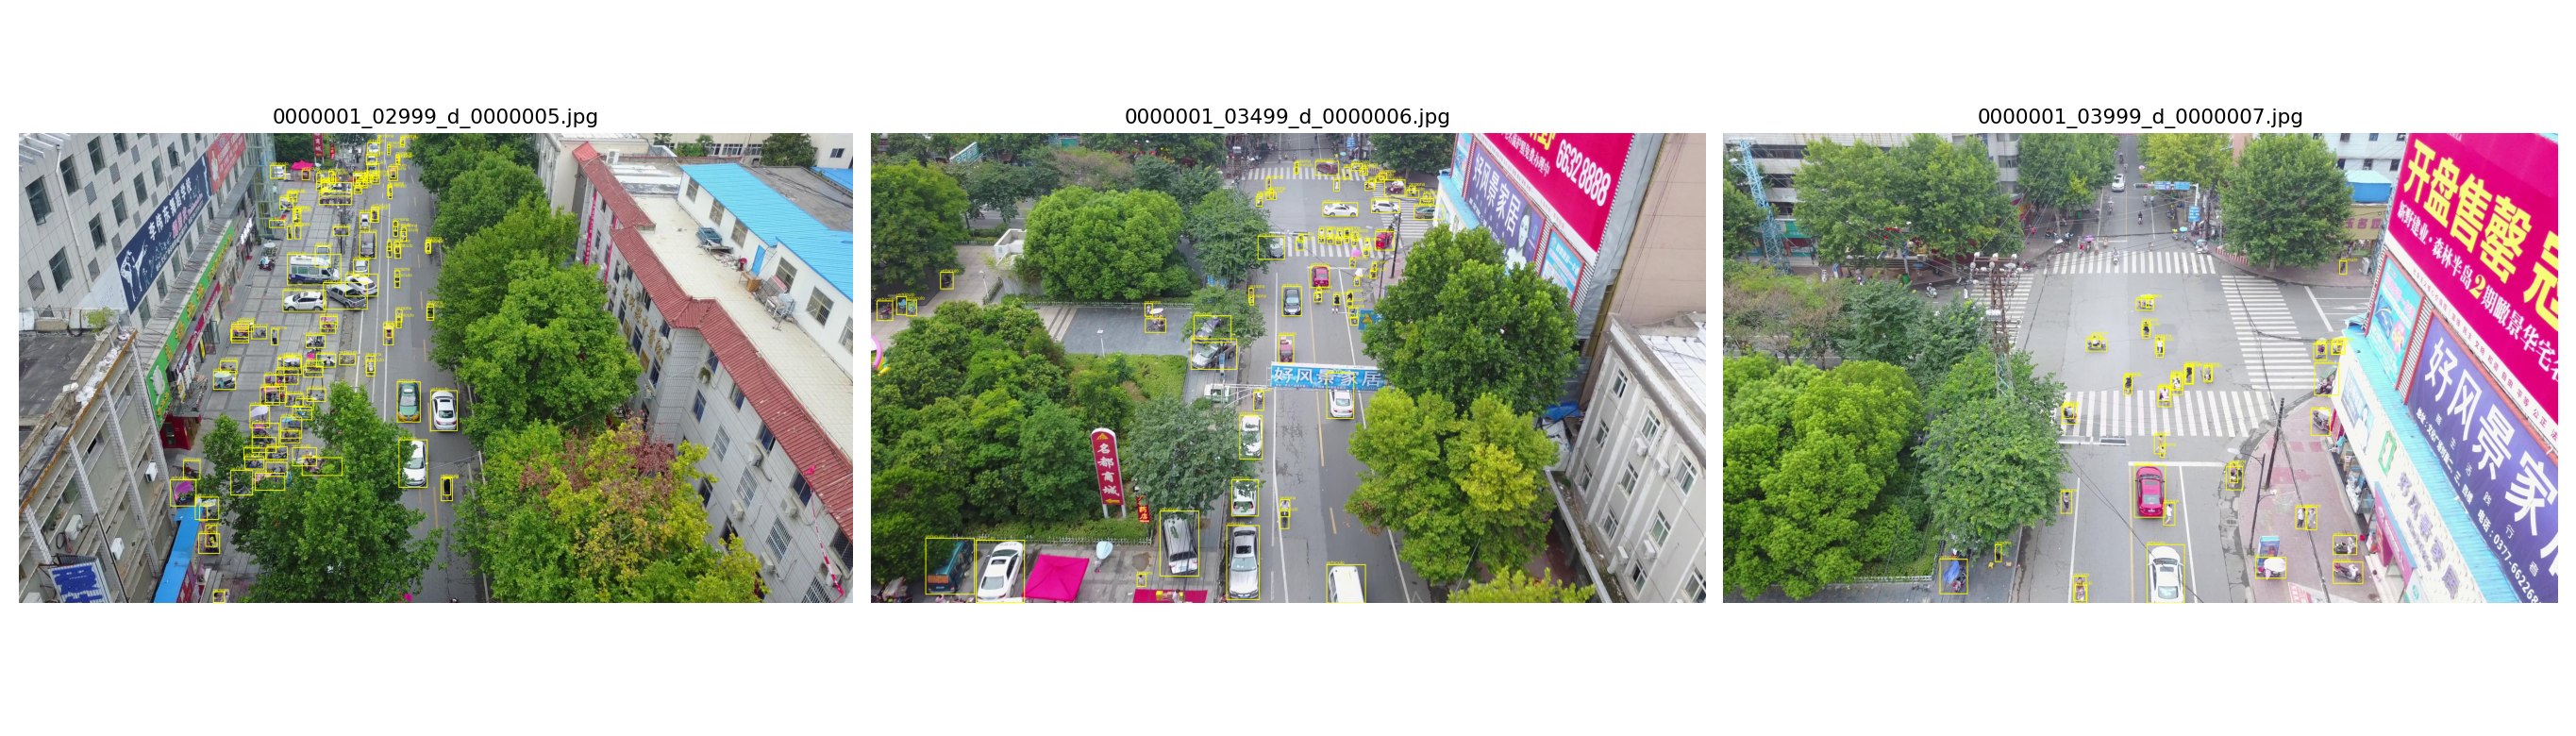

*Figura 1. Cajas convertidas sobre tres imágenes de validación. La revisión visual complementa los controles automáticos.*

In [3]:
view.figure(ctx, 'data/box_review.png', 'Figura 1. Cajas convertidas sobre tres imágenes de validación. La revisión visual complementa los controles automáticos.')

### Distribución de clases y tamaños
El número de anotaciones por clase describe el desbalance del conjunto. El cociente entre el área de cada caja y el área de la imagen caracteriza el tamaño relativo de los objetos.

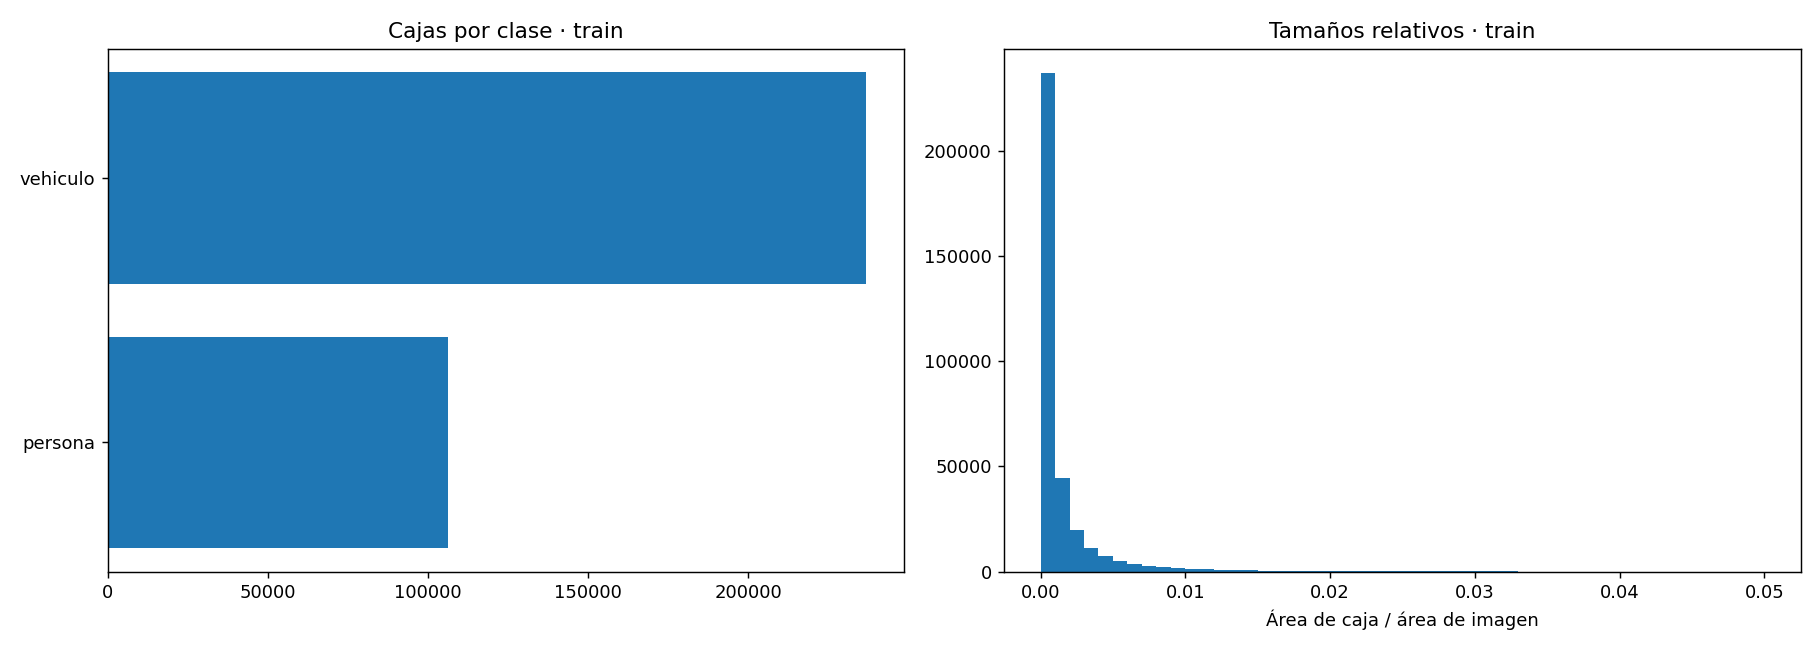

*Figura 2. Distribución de clases y áreas relativas en train. El histograma representa el intervalo indicado en su eje horizontal.*

In [4]:
view.figure(ctx, 'data/audit.png', 'Figura 2. Distribución de clases y áreas relativas en train. El histograma representa el intervalo indicado en su eje horizontal.')

## 4. Metodología experimental
Se utilizó aprendizaje por transferencia y una semilla fija. Las particiones oficiales se conservaron durante el procesamiento. La selección del checkpoint se realizó con validación; todas las cifras de una evaluación provienen del mismo modelo y protocolo.

El trabajo tiene dos etapas:

1. **Línea base.** YOLO11n y YOLO26n se entrenaron a 640 px con las diez categorías de VisDrone y obtuvieron precisión equivalente en validación (mAP@0.5 de 28,4 % y 28,5 %). Se eligió YOLO26n porque su salida no requiere NMS, lo que simplifica la ejecución en las placas. Sus predicciones se agruparon después en persona y vehículo para evaluar la misión (secciones 9 a 12).
2. **Reentrenamiento.** Esas evaluaciones mostraron que el límite es el tamaño aparente de los objetos. Por eso ambos modelos se entrenaron de nuevo con persona y vehículo desde las etiquetas y con entrada de 1280 px, la configuración de la misión. Desde la sección 6, los resultados corresponden a YOLO26n reentrenado; la sección 11 lo compara con la línea base y con YOLO11n.

La tabla presenta el presupuesto de entrenamiento y el entorno de YOLO26n reentrenado.

In [5]:
view.protocol(ctx)

| Variable | Configuración experimental |
|---|---|
| Modelo / inicialización | yolo26n.pt · pesos preentrenados COCO |
| Épocas configuradas | 50 |
| Train / val | split completo / split completo imágenes |
| Resolución / batch / semilla | 1280 px / 4 / 42 |
| GPU | NVIDIA GeForce RTX 5070 Laptop GPU |
| PyTorch / Ultralytics | 2.13.0+cu130 / 8.4.162 |

### Ajuste y selección del modelo
El entrenamiento actualiza los pesos con las imágenes de train y, al terminar, evalúa en validación el checkpoint seleccionado por Ultralytics (`best.pt`). La celda siguiente reentrena con el perfil `full` de `config.yaml`. Está desactivada por defecto; al activarla, la predicción de cada época aparece en su salida y las secciones siguientes pasan a mostrar esa ejecución. La tabla posterior lista las ejecuciones full registradas y su estado.

In [ ]:
# True reentrena con el perfil full de config.yaml (1280 px, persona y vehículo): unas 4 h por modelo en la laptop.
ENTRENAR = False
USAR_YOLO26 = True  # False entrena YOLO11n

if ENTRENAR:
    if IS_COLAB:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics==8.4.162'], check=True)
    if not (ROOT / 'data' / 'visdrone.yaml').exists():
        from tp4.data import prepare_all
        prepare_all(ROOT / 'data')  # descarga y convierte VisDrone2019-DET (unos 2 GB)
    from tp4.experiment import train
    RUN_ID = train(ROOT, 'full', use_yolo26=USAR_YOLO26).relative_to(ROOT).as_posix()
    ctx = view.context(ROOT, RUN_ID, final_only=True)

In [7]:
view.runs_table(ctx)

| Ejecución | Modelo | Entrada | Clases | Estado | mAP@0.5 (val) |
|---|---|---|---|---|---|
| 20260925T012307Z | yolo11n | 640 px | 10 | incompleta · 6 épocas, sin cierre | — |
| 20260925T015117Z | yolo11n | 640 px | 10 | terminada | 28,4 % |
| 20260925T231501Z | yolo26n | 640 px | 10 | terminada | 28,5 % |
| 20260927T215941Z | yolo11n | 1280 px | 2 | terminada | 69,7 % |
| 20260928T003017Z | yolo26n | 1280 px | 2 | terminada | 70,4 % |

El mAP con 10 clases y con 2 clases no se compara entre sí. De las ejecuciones en curso no se informan métricas parciales.

### Predicciones a lo largo del entrenamiento
Al finalizar cada época se selecciona de forma aleatoria reproducible una imagen de **test-dev**, ajena a train y val, y se muestran las detecciones de los pesos EMA de esa época con confianza mínima 0,25. Cada salida conserva la época y el nombre de la imagen. La celda muestra la última ejecución full con vistas guardadas. La secuencia permite explorar el comportamiento de la red; al cambiar de escena, las diferencias visuales no equivalen a una medida de mejora.

Este seguimiento utiliza imágenes de test-dev sin sus etiquetas y sin actualizar pesos con ellas. En las ejecuciones que lo activan, test-dev es un conjunto observado durante el entrenamiento; su evaluación posterior debe interpretarse con esa limitación.

In [ ]:
from tp4.epoch_preview import show_history

RUN_EVOLUTION = None  # o 'runs/full/ID'
WATCH_EPOCHS = False
show_history(ROOT, run=RUN_EVOLUTION, watch=WATCH_EPOCHS)

## 5. Criterios de evaluación
Una detección correcta requiere acertar la clase y alcanzar el solapamiento exigido. La **IoU** es el cociente entre el área de intersección y el área de unión de las cajas.

| Métrica | Definición | Interpretación |
|---|---|---|
| Precision | TP / (TP + FP) | Proporción de predicciones correctas |
| Recall | TP / (TP + FN) | Proporción de objetos encontrados |
| mAP@0.5 | Media entre clases del área bajo la curva precision–recall, con IoU 0,5 | Calidad de detección con localización moderada |
| mAP@0.5:0.95 | Media entre clases y diez umbrales de IoU de 0,50 a 0,95 | Exigencia mayor sobre la localización |

Se emplea el evaluador estándar de Ultralytics. Excluir etiquetas de regiones ignoradas no reproduce necesariamente el tratamiento del evaluador oficial de VisDrone; las cifras no se presentan como resultados oficiales de ese benchmark.

## 6. Resultados de validación
Las métricas se expresan como porcentajes y se interpretan bajo el protocolo descrito. Precision y recall resumen el punto de operación del evaluador, mientras que AP integra distintos umbrales de confianza.

In [9]:
view.metrics(ctx)

| Evaluación | Precision (%) | Recall (%) | mAP@0.5 (%) | mAP@0.5:0.95 (%) |
|---|---|---|---|---|
| Validación | 79.3706 | 62.2830 | 70.4231 | 39.9809 |

Porcentajes sobre la validación de esta ejecución. P/R agregadas por el evaluador; no corresponden necesariamente al umbral 0,25 de la galería. Métricas estándar de Ultralytics, no del evaluador oficial VisDrone.

### Resultados por clase
El desglose permite identificar diferencias entre categorías. Estas diferencias se consideran junto con su frecuencia en el conjunto y los ejemplos de detección.

In [10]:
view.metrics(ctx, per_class=True)

| Clase | Precision (%) | Recall (%) | mAP@0.5 (%) | mAP@0.5:0.95 (%) |
|---|---|---|---|---|
| persona | 74.3601 | 52.6022 | 60.0384 | 27.0944 |
| vehiculo | 84.3811 | 71.9637 | 80.8079 | 52.8674 |

Porcentajes sobre la validación de esta ejecución. P/R agregadas por el evaluador; no corresponden necesariamente al umbral 0,25 de la galería. Métricas estándar de Ultralytics, no del evaluador oficial VisDrone.

### Evolución del ajuste y matriz de confusión
Las curvas describen la evolución de pérdidas y métricas a lo largo del entrenamiento. La matriz resume asociaciones entre clases y errores con el fondo para la validación del modelo.

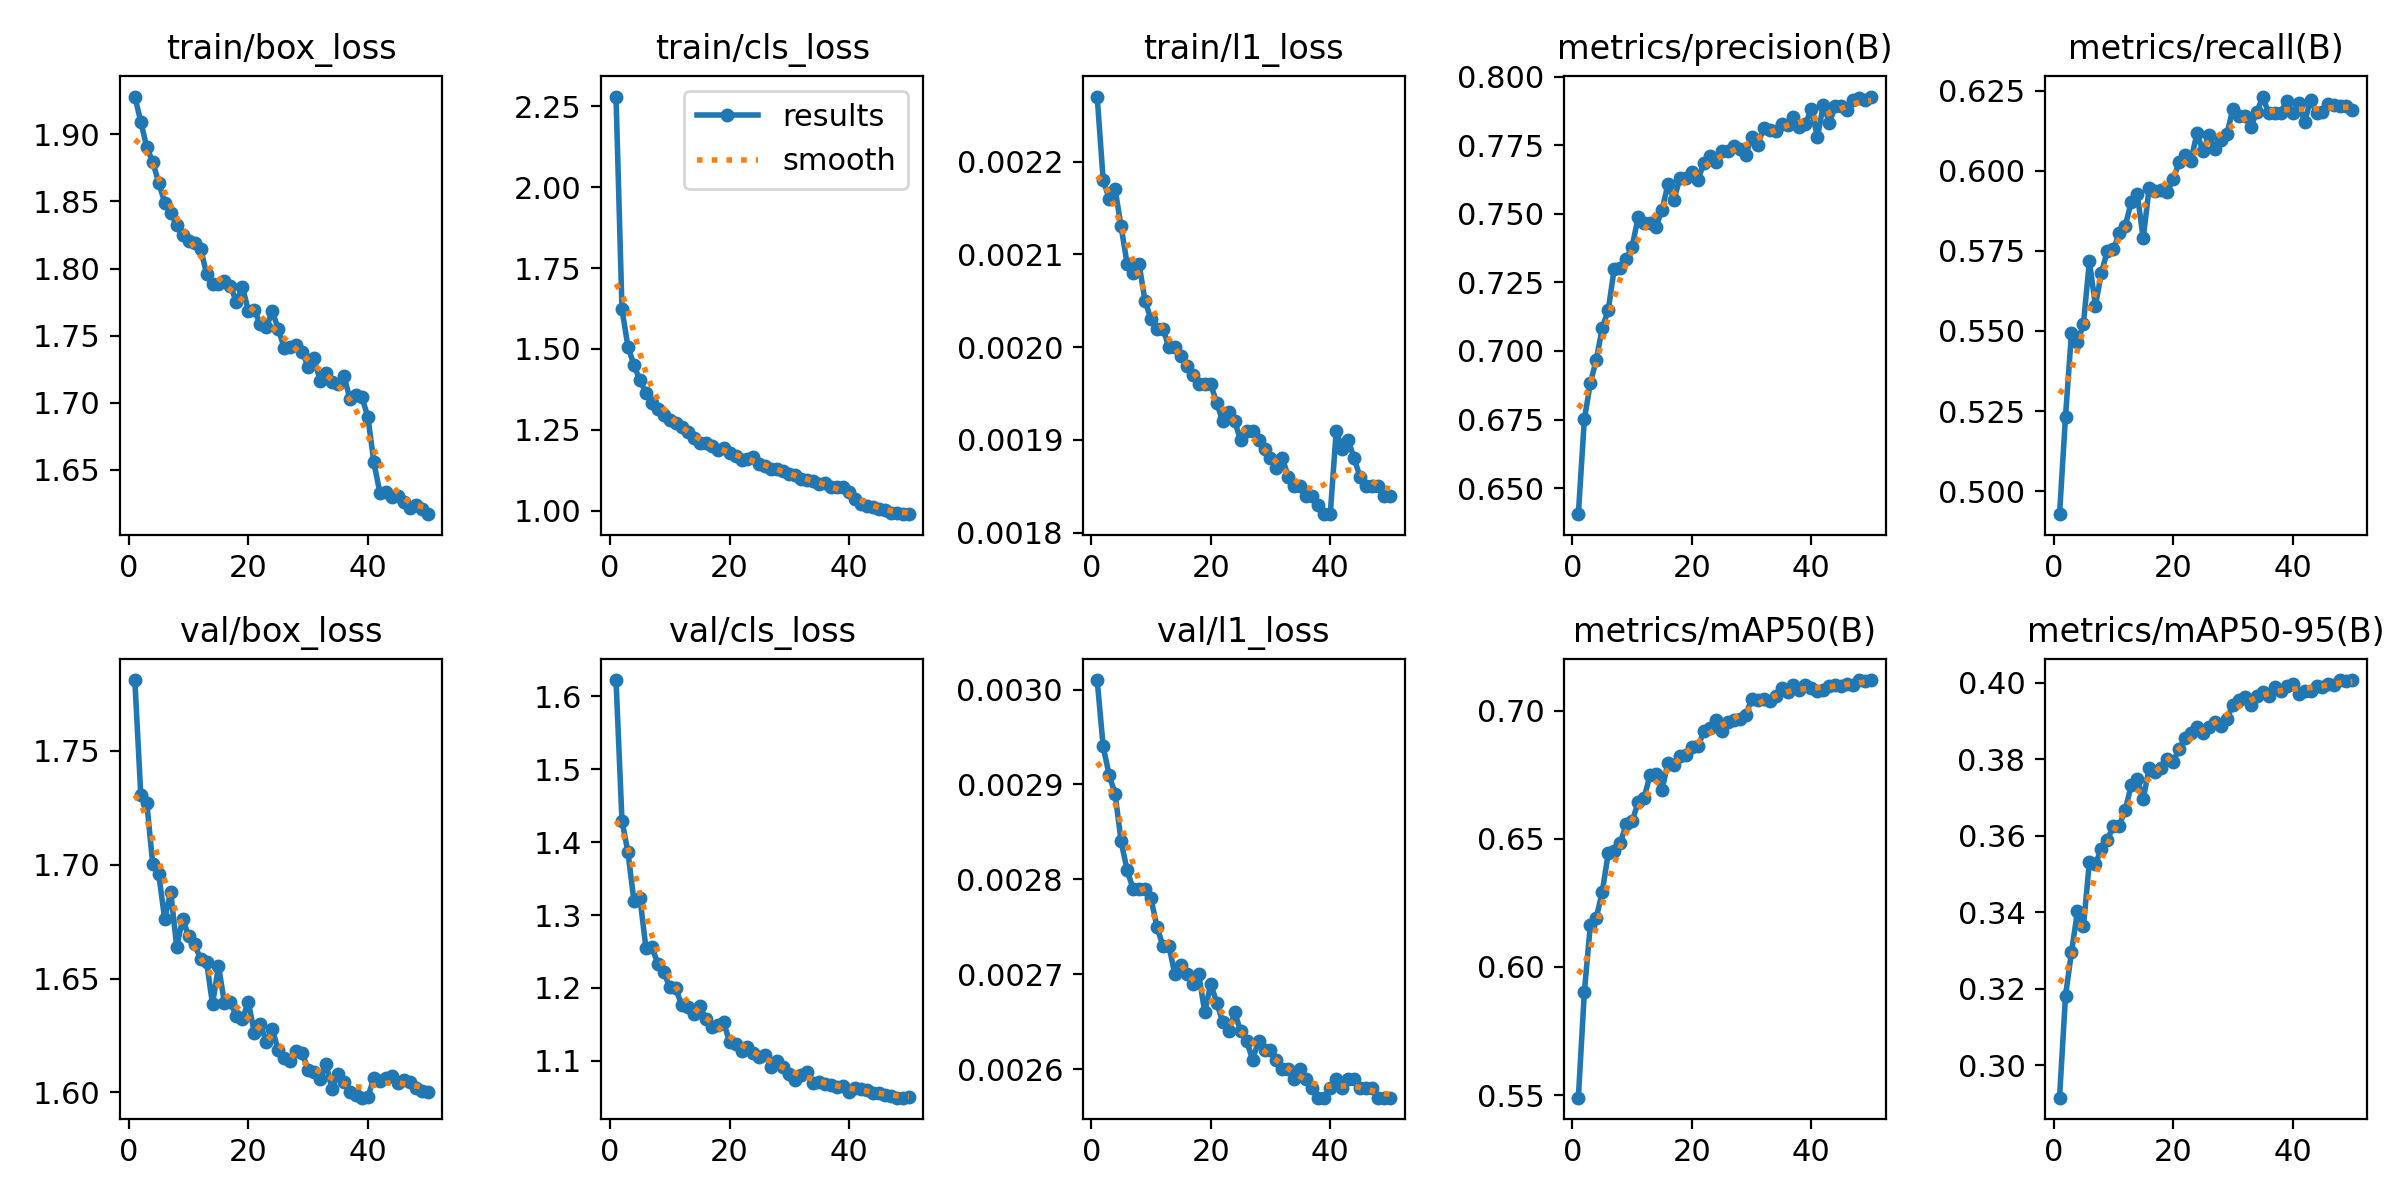

*Figura 3. Pérdidas de entrenamiento y evolución de las métricas de validación.*

In [11]:
view.figure(ctx, 'train/results.png', 'Figura 3. Pérdidas de entrenamiento y evolución de las métricas de validación.', run=True)

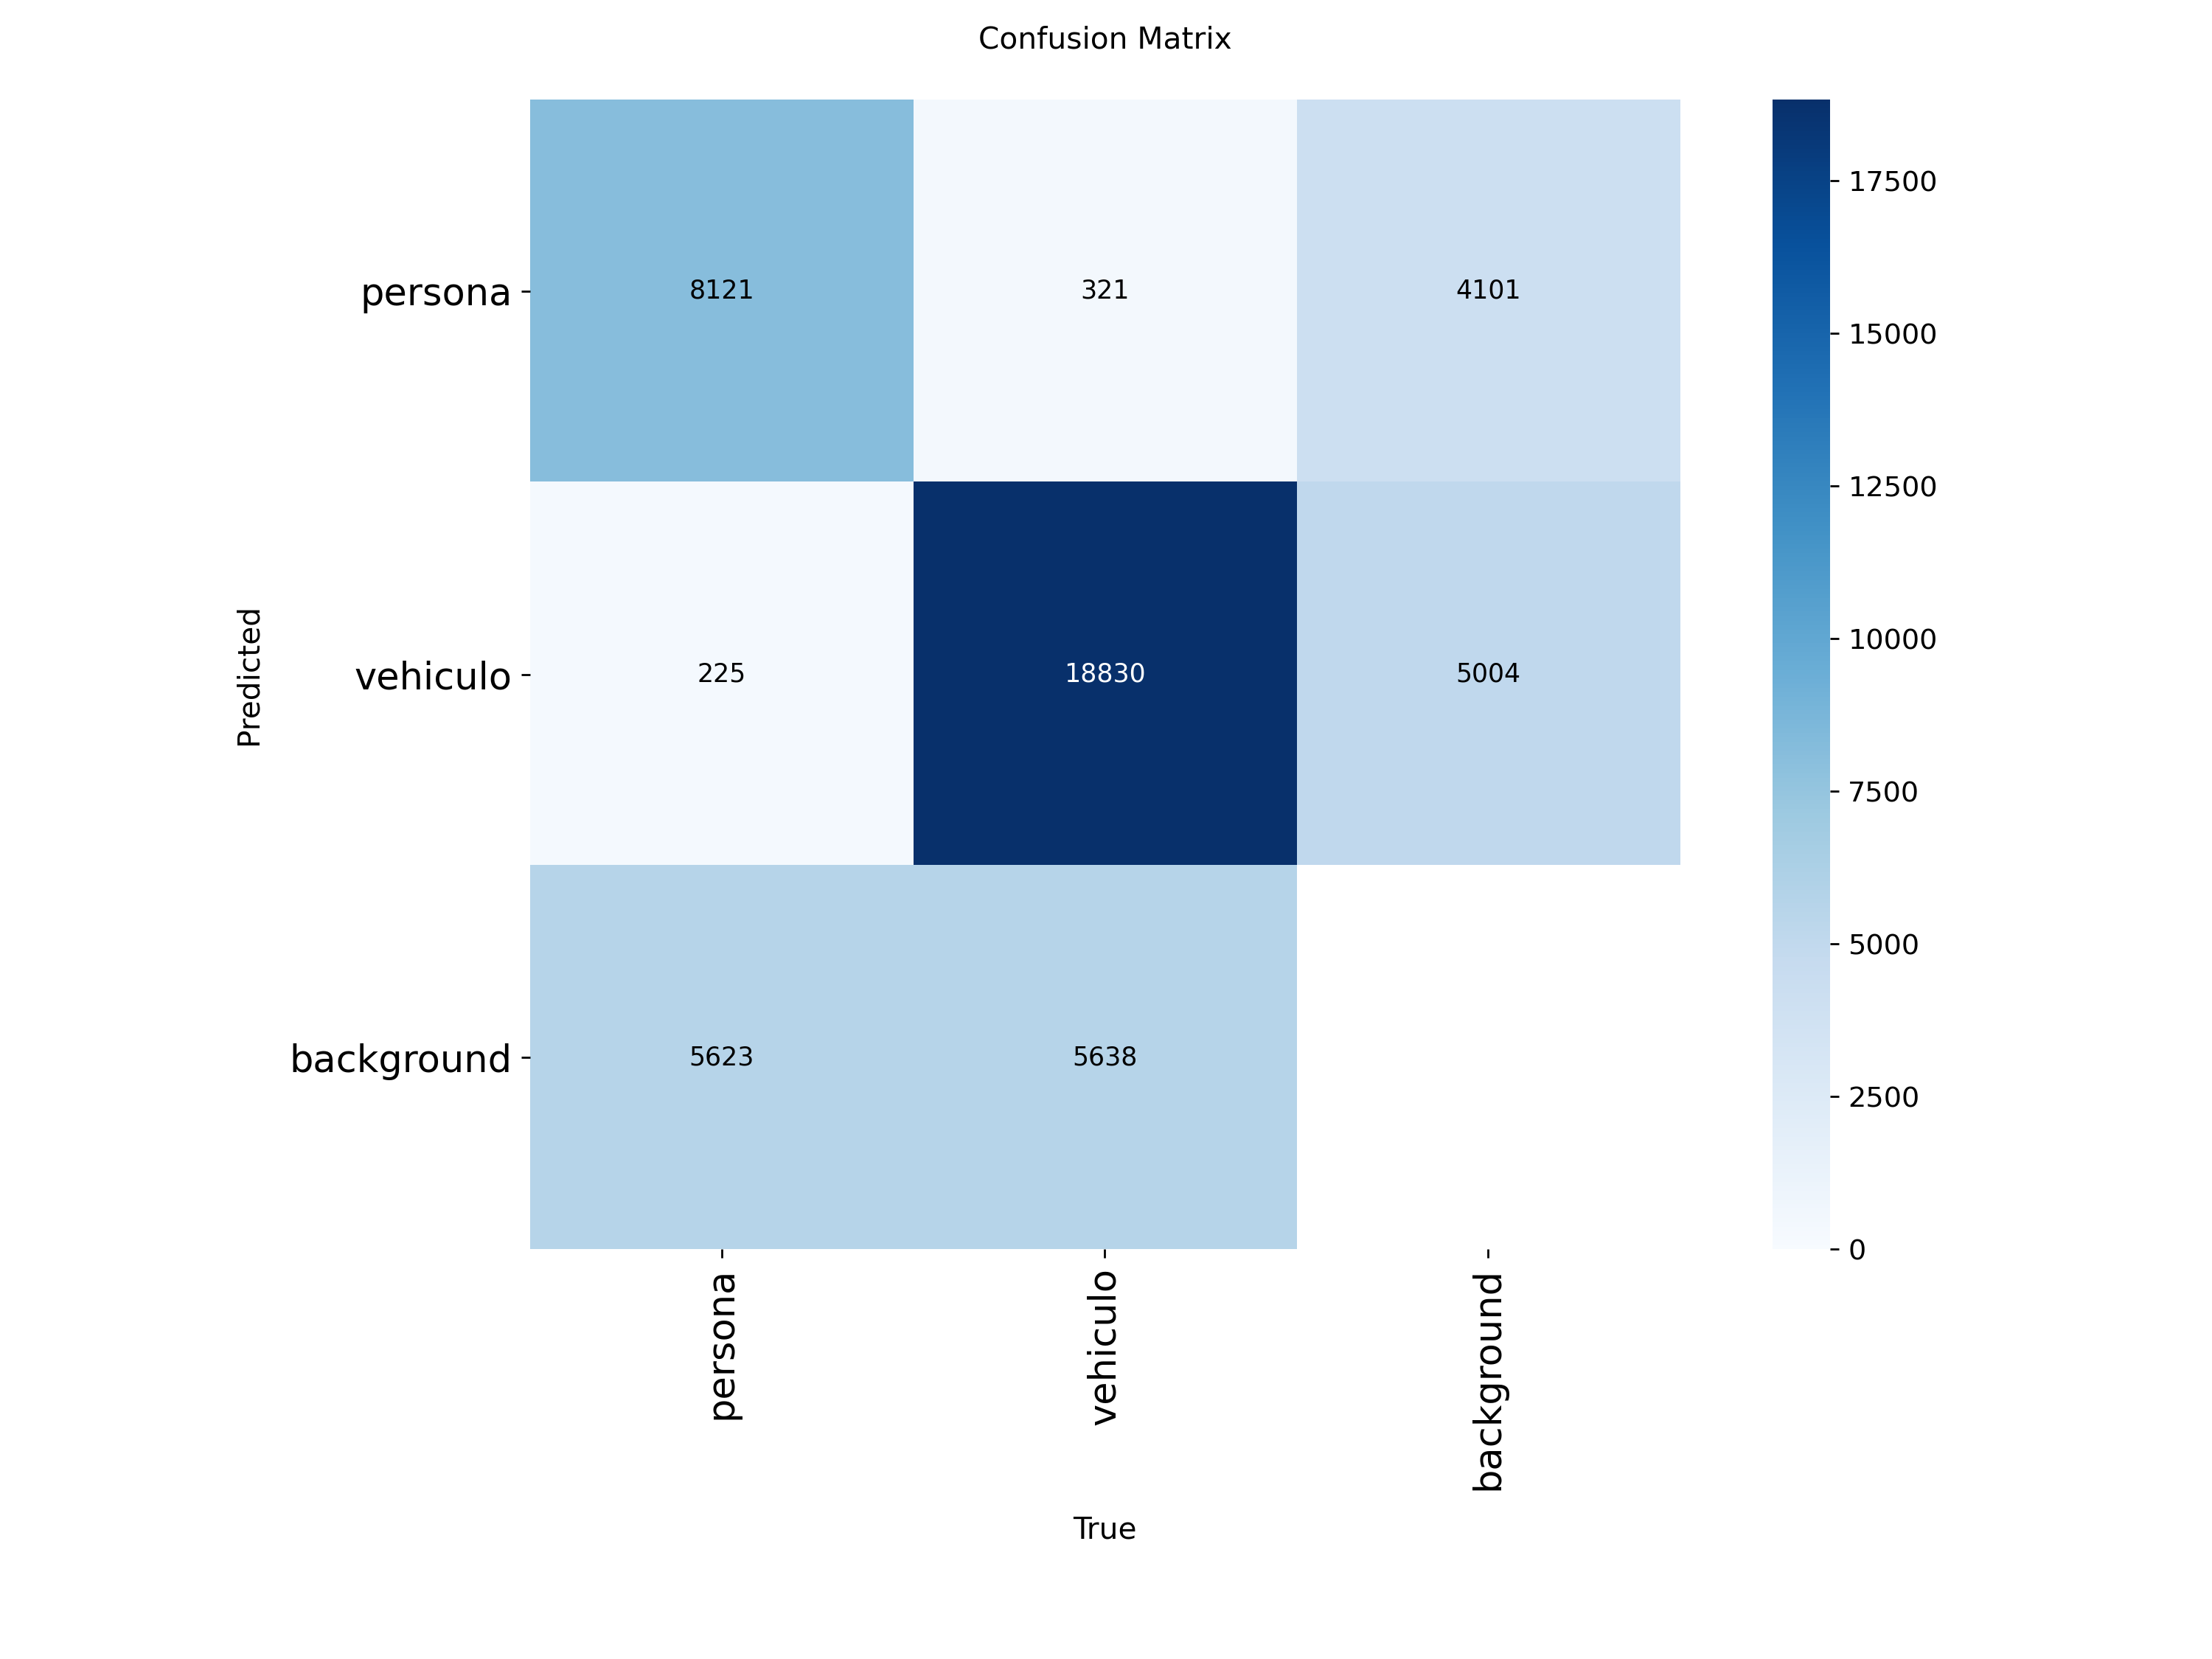

*Figura 4. Matriz de confusión del evaluador Ultralytics sobre validación.*

In [12]:
view.figure(ctx, 'validation/confusion_matrix.png', 'Figura 4. Matriz de confusión del evaluador Ultralytics sobre validación.', run=True)

## 7. Análisis de errores
El análisis de ejemplos de validación utiliza confianza 0,25 y asociación uno a uno por clase e IoU 0,5. Los conteos corresponden a una muestra de imágenes y no equivalen al mAP, que integra un barrido de confianza.

In [13]:
view.errors(ctx)

| Imágenes | Confianza | IoU de asociación | TP | FP | FN |
|---|---|---|---|---|---|
| 8 | 0.25 | 0.5 | 565 | 263 | 306 |

Asociación uno a uno, misma clase e IoU ≥ umbral. Son conteos de una muestra, no métricas de todo el conjunto.

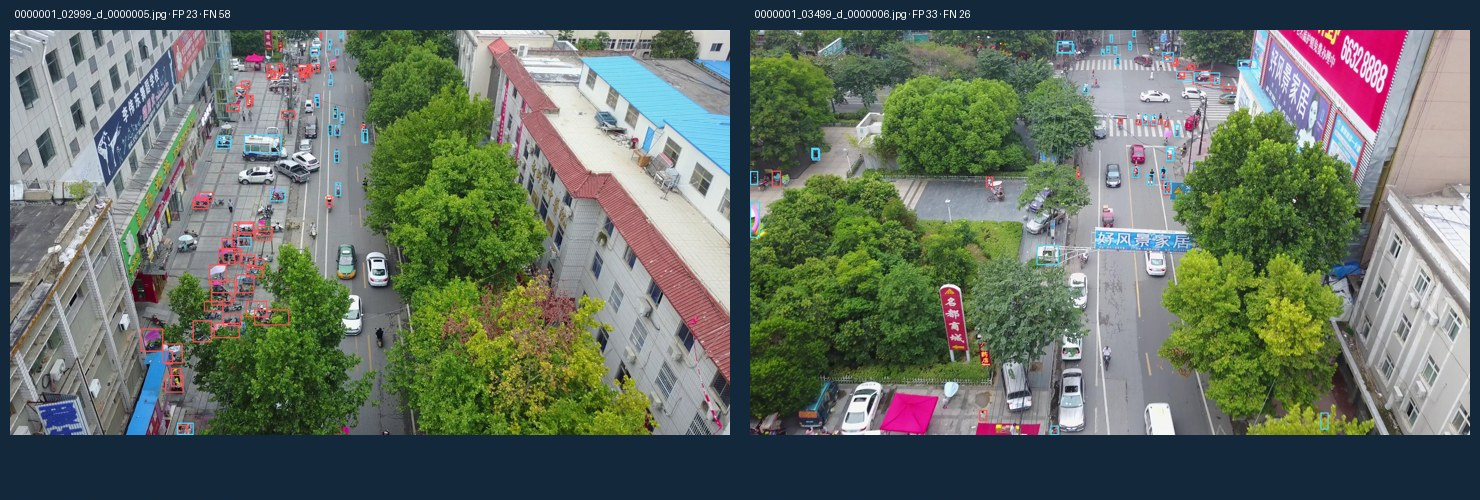

*Figura 5. Dos ejemplos de la muestra analizada: rojo indica falsos negativos y cian, falsos positivos.*

In [14]:
view.figure(ctx, 'error_gallery.jpg', 'Figura 5. Dos ejemplos de la muestra analizada: rojo indica falsos negativos y cian, falsos positivos.', run=True, first_row=True)

### Comparación visual con las anotaciones
La comparación del mismo lote muestra diferencias de ubicación, categoría y cobertura entre las anotaciones y las predicciones.

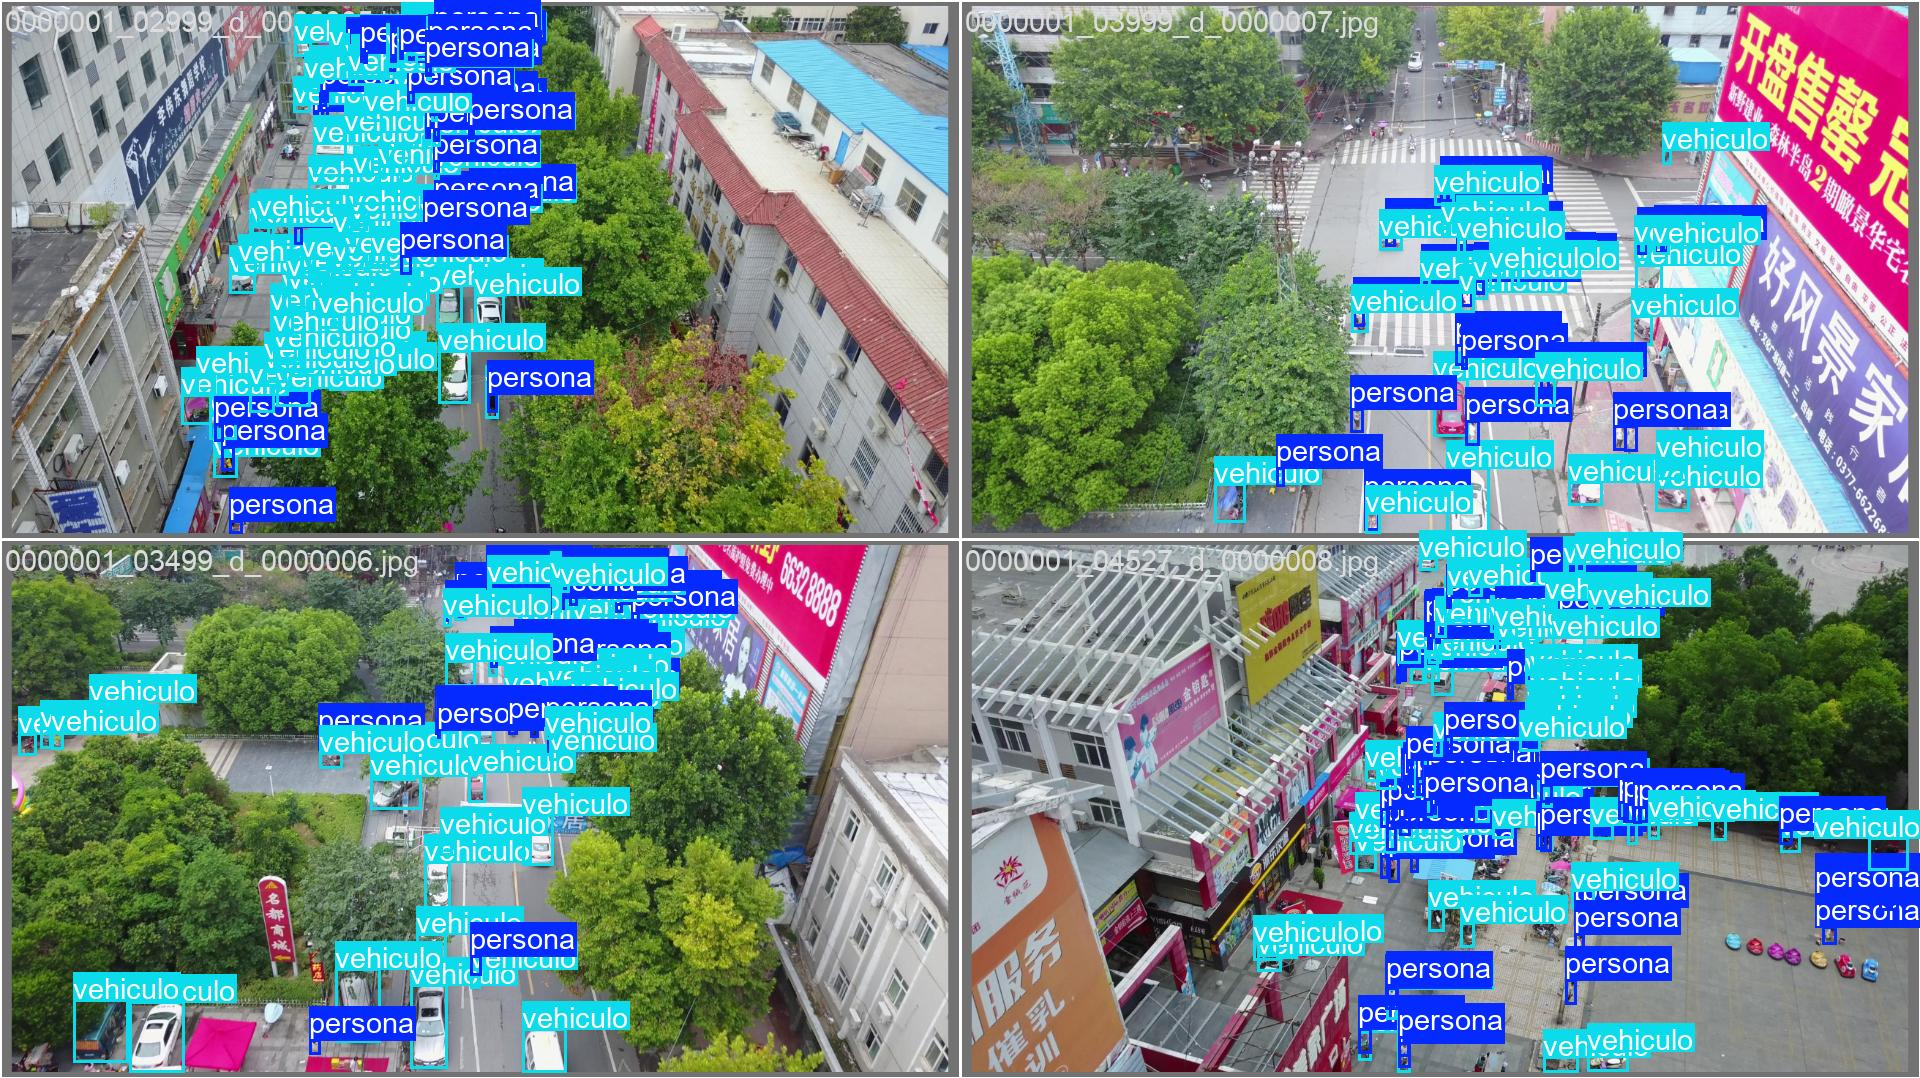

*Figura 6. Anotaciones de referencia del primer lote de validación.*

In [15]:
view.figure(ctx, 'validation/val_batch0_labels.jpg', 'Figura 6. Anotaciones de referencia del primer lote de validación.', run=True)

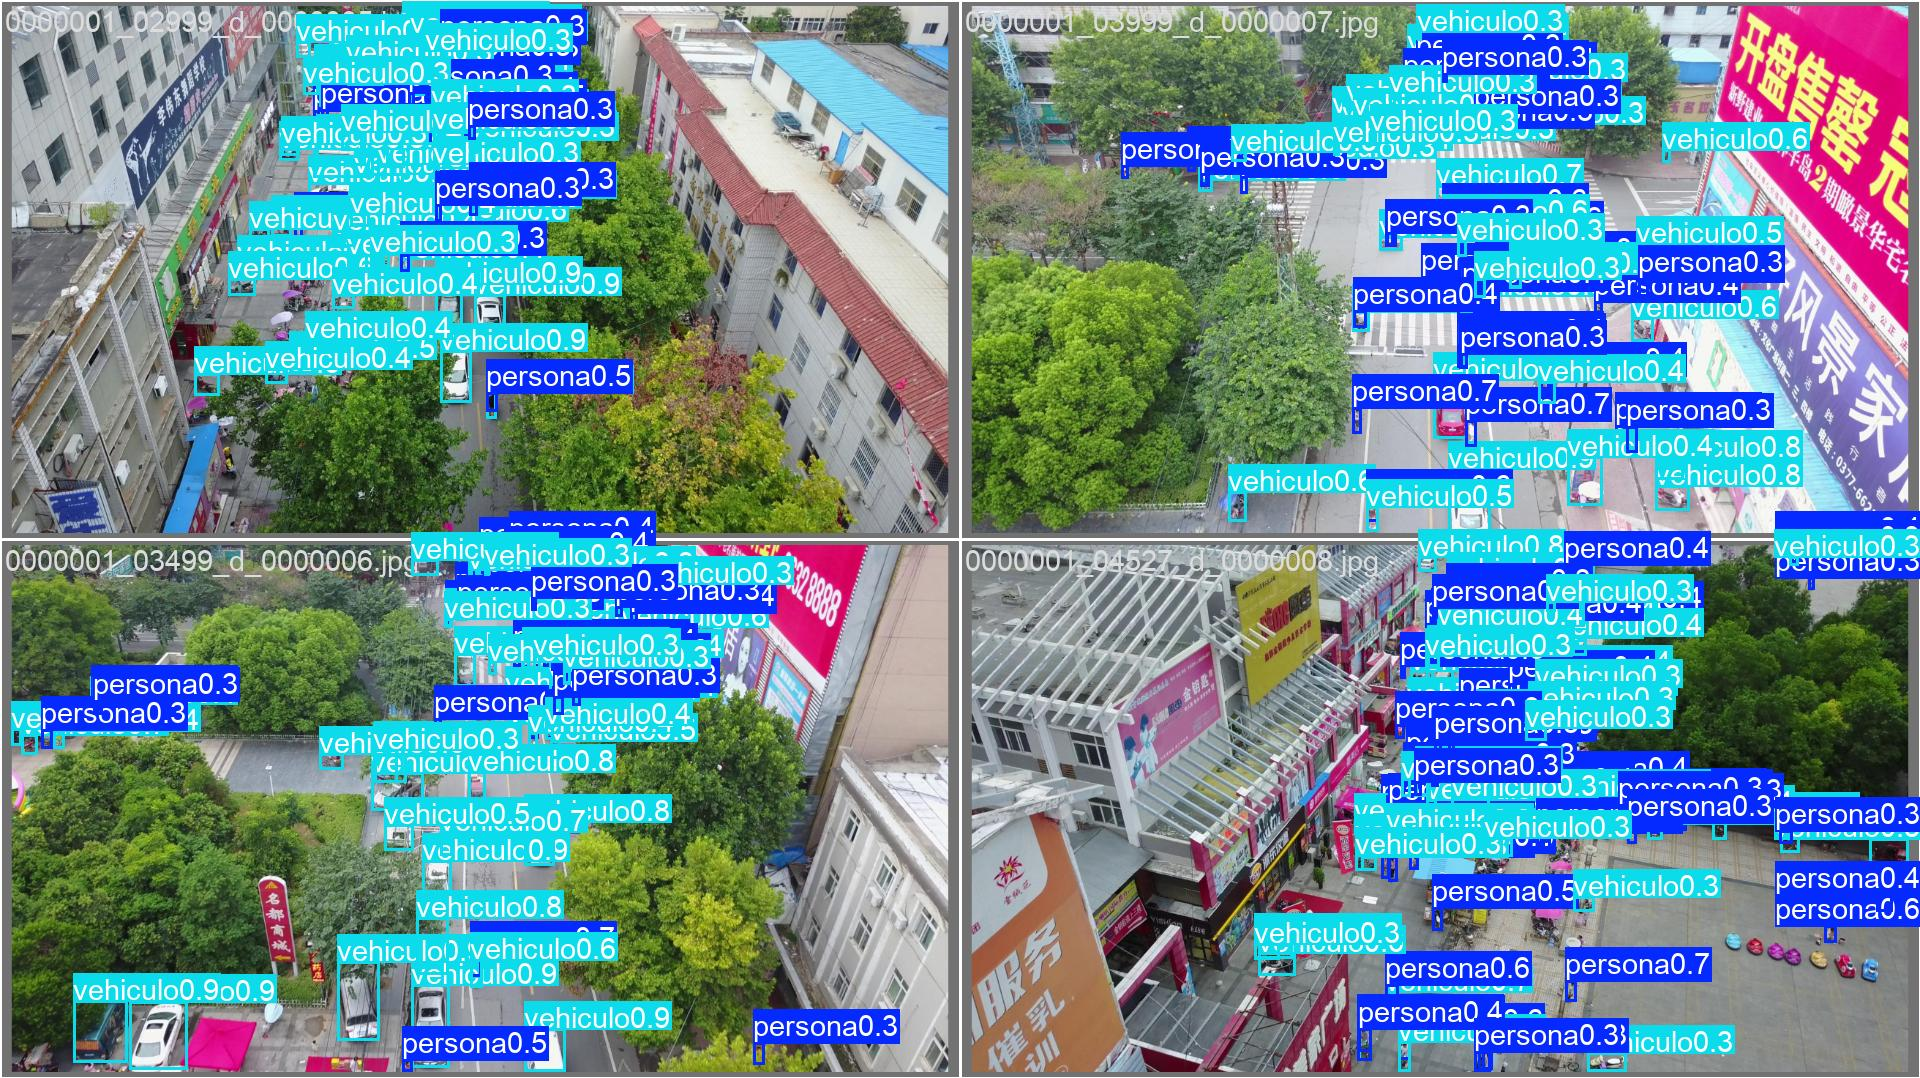

*Figura 7. Predicciones correspondientes al mismo lote de validación.*

In [16]:
view.figure(ctx, 'validation/val_batch0_pred.jpg', 'Figura 7. Predicciones correspondientes al mismo lote de validación.', run=True)

## 8. Coste de inferencia
La latencia corresponde a una llamada completa de predicción, con batch 1, calentamiento y sincronización CUDA. La medición caracteriza el entorno local utilizado.

In [17]:
view.latency(ctx)

| Tiempo por imagen | GPU | Resolución / batch | Calentamiento / repeticiones |
|---|---|---|---|
| 29.50 ms | NVIDIA GeForce RTX 5070 Laptop GPU | 1280 / 1 | 5 / 20 |

Condición: predict completo, una imagen repetida. Una imagen repetida no representa la variabilidad de escenas ni el rendimiento en un dron.

## 9. Del laboratorio al dron: clases y objetivo
Las clases del trabajo ya responden a la misión: **persona** y **vehículo**. Falta fijar un objetivo operativo:

**Detectar al menos una vez durante la pasada el 85 % de las personas, con el modelo optimizado a 5 FPS o más en la placa.**

A 10 m/s, 5 FPS equivale a 2 m recorridos entre detecciones.

In [18]:
view.mission_classes(ctx)

| Clase de la misión | Clases VisDrone | Objetos (val) | AP50 | Precisión / recall por cuadro |
|---|---|---|---|---|
| persona | pedestrian, people | 13969 | 60,0 % | 64,1 % / 57,6 % |
| vehiculo | car, van, truck, bus, tricycle, awning-tricycle, bicycle, motor | 24789 | 80,8 % | 77,9 % / 75,6 % |

Modelo entrenado con persona y vehículo (1280 px, confianza 0,25, IoU 0,5). El conductor de una moto o bicicleta está anotado como persona; el vehículo que conduce, como vehículo.

## 10. Resolución de entrada
Al reducir la imagen a 640 px, casi la mitad de las personas mide menos de 8 px. Con el modelo de línea base, procesar la imagen completa a mayor resolución o cortarla en mosaicos al estilo de SAHI [4] recuperó personas sin reentrenar, y eso motivó reentrenar a 1280 px. La tabla evalúa el modelo reentrenado con las mismas variantes: entrenado a 1280 px, necesita esa entrada; a 640 px pierde casi toda la mejora. Sumar mosaicos a la imagen completa a 1280 px casi no cambia el mAP y agrega unos 5 puntos de recall de personas, a cambio de unas seis inferencias por imagen. En DET val, los mosaicos sobre la imagen reducida a 1920 o 2560 px coinciden con los nativos, porque ninguna imagen supera los 1920 px.

In [19]:
view.resolution(ctx)

| Variante | Inferencias por imagen | ms por imagen (laptop) | mAP50 misión | Recall persona | Recall vehículo |
|---|---|---|---|---|---|
| Imagen completa 640 px | 1,0 | 20 | 49,9 % | 33,4 % | 58,9 % |
| Imagen completa 960 px | 1,0 | 25 | 63,2 % | 49,5 % | 70,7 % |
| Imagen completa 1280 px | 1,0 | 27 | 69,9 % | 57,4 % | 75,8 % |
| Mosaicos nativos | 6,2 | 84 | 64,7 % | 59,5 % | 77,8 % |
| Mosaicos nativos + 1280 px | 6,2 | 85 | 70,0 % | 62,3 % | 79,6 % |

Mismo `best.pt` en todas las variantes, en las 548 imágenes de validación de DET. Recall por cuadro con confianza 0,25. El tiempo es de la GPU de la laptop: en una placa el costo crece cerca de la cantidad de píxeles.

## 11. Detección durante la pasada
En video, cada persona aparece en muchos cuadros y basta con detectarla una vez. Con los identificadores por objeto de VisDrone-VID [5] se mide qué fracción de objetos se detecta al menos una vez, simulando los FPS que sostiene una placa. Cuatro de las siete secuencias comparten video de origen con el entrenamiento de DET y se excluyen.

In [20]:
view.pass_detection(ctx)

| Variante | Inferencias por cuadro | Personas a 10 FPS | Personas a 5 FPS | Personas a 2 FPS | Vehículos a 5 FPS |
|---|---|---|---|---|---|
| Imagen completa 640 px | 1,0 | 81,3 % | 78,6 % | 73,9 % | 56,2 % |
| Imagen completa 1280 px | 1,0 | 90,9 % | 88,8 % | 86,4 % | 65,2 % |
| Mosaicos sobre imagen de 1920 px | 8,5 | 94,1 % | 93,0 % | 90,8 % | 68,5 % |
| Mosaicos nativos + 1280 px | 23,5 | 96,8 % | 95,2 % | 91,8 % | 71,9 % |

Objetos detectados al menos una vez durante la pasada, en las 3 secuencias de VisDrone-VID que no comparten video con el entrenamiento (187 personas). Confianza 0,25 y 30 FPS nominales. **Objetivo: 85 % de las personas a 5 FPS o más.** Con 1280 px: 88,8 % a 5 FPS y 90,9 % a 10 FPS.

### Efecto del reentrenamiento
Misma variante (imagen completa a 1280 px) y mismo procedimiento de evaluación para el modelo de línea base, entrenado a 640 px con diez categorías y reagrupado, y para los dos modelos reentrenados con persona y vehículo a 1280 px. Reentrenar sube el recall de personas por cuadro de 43 % a 57 % sin aumentar las falsas alarmas, y recupera las personas grandes que el modelo de 640 px perdía al inferir a 1280 px. YOLO11n y YOLO26n reentrenados vuelven a ser equivalentes en detección; YOLO26n comete menos falsas alarmas y no requiere NMS, por lo que sigue siendo el modelo de las placas. Los vehículos pequeños del video 4K siguen sin alcanzarse.

In [21]:
view.retraining(ctx, {
    'Línea base: YOLO26n, 640 px, 10 clases reagrupadas': 'runs/full/20260925T231501Z',
    'YOLO11n reentrenado': 'runs/full/20260927T215941Z',
    'YOLO26n reentrenado': 'runs/full/20260928T003017Z',
})

| Modelo | mAP50 misión (DET val) | Recall persona por cuadro | Recall vehículo por cuadro | Personas por pasada a 5 FPS | Vehículos por pasada a 5 FPS | Falsas personas por cuadro |
|---|---|---|---|---|---|---|
| Línea base: YOLO26n, 640 px, 10 clases reagrupadas | 61,4 % | 42,9 % | 65,9 % | 84,0 % | 64,0 % | 7,0 |
| YOLO11n reentrenado | 69,3 % | 57,3 % | 75,7 % | 89,8 % | 65,2 % | 8,0 |
| YOLO26n reentrenado | 69,9 % | 57,4 % | 75,8 % | 88,8 % | 65,2 % | 6,9 |

Imagen completa 1280 px, mismo pipeline de predicción para todos los modelos. Por cuadro: DET val con confianza 0,25. Por pasada: secuencias limpias de VisDrone-VID, confianza 0,25.

## 12. Demostración: el modelo durante una pasada

In [ ]:
view.video_demo(ctx)

## 13. Siguiente paso: benchmark en placas
La configuración por defecto es la **imagen completa a 1280 px**, con una inferencia por cuadro. El benchmark compara YOLO26n original (`.pt`) con su versión optimizada en cada placa:

| Placa | Referencia | Optimizado |
|---|---|---|
| NVIDIA Jetson (con GPU) | PyTorch FP32 | TensorRT FP16 |
| Raspberry Pi 5 (sin GPU) | PyTorch FP32 | NCNN, 4 hilos |

Los FPS que sostenga cada placa se cruzan con la tabla de detección durante la pasada: con el modelo reentrenado a 1280 px, la detección por pasada supera el 85 % incluso a 2 FPS, así que el objetivo se cumple si la placa sostiene los 5 FPS del requisito. El paquete común (300 imágenes de test-dev, 1280 px) está preparado y verificado con YOLO26n reentrenado, con persona y vehículo. La demostración en vivo prevista corre el benchmark por SSH en una placa.

## 14. Discusión y conclusiones
**Misión embarcada.** El límite de la línea base era el tamaño aparente de los objetos: con 640 px, casi la mitad de las personas mide menos de 8 px. Entrenar con persona y vehículo a 1280 px lleva la detección por pasada a 89 % de las personas a 5 FPS y 86 % a 2 FPS, frente a 84 % y 80 % del modelo de línea base inferido a 1280 px, con las mismas falsas alarmas (unas 7 personas falsas por cuadro con confianza 0,25). Quedan como limitaciones los vehículos muy pequeños en video 4K y esas falsas alarmas en escenas densas. El paso siguiente es medir en las placas los FPS que sostiene YOLO26n a 1280 px.

**Detector en validación:**

In [23]:
view.conclusion(ctx)

**Resultado de validación (yolo26n, 1280 px, 2 clases):** mAP@0.5 **70.4231%** y mAP@0.5:0.95 **39.9809%**. Estos valores caracterizan la detección en el conjunto de validación. La diferencia entre ambos criterios refleja el efecto de exigir una localización más precisa.

### Alcance de las conclusiones
Las métricas de validación corresponden a imágenes estáticas, y la detección por pasada se apoya en solo tres secuencias de video limpias (187 personas). Hay una única semilla de entrenamiento: no se estimó variabilidad entre entrenamientos ni desempeño por oclusión. Los ejemplos visuales permiten describir errores, pero no atribuir causalmente su origen.

La latencia sobre una imagen repetida no representa la variabilidad entre escenas ni el rendimiento de hardware embarcado. Estas condiciones delimitan la interpretación de las métricas para aplicaciones robóticas.

## 15. Referencias
1. Zhu et al. *Detection and Tracking Meet Drones Challenge*. IEEE Transactions on Pattern Analysis and Machine Intelligence, 44(11), 7380–7399, 2022. [Repositorio y dataset](https://github.com/VisDrone/VisDrone-Dataset).
2. Ultralytics. [VisDrone: categorías, particiones y formato de anotaciones](https://docs.ultralytics.com/datasets/detect/visdrone/).
3. Ultralytics. [YOLO11](https://docs.ultralytics.com/models/yolo11/), [YOLO26](https://docs.ultralytics.com/models/yolo26/) y [entrenamiento](https://docs.ultralytics.com/modes/train/).
4. Akyon, Altinuc y Temizel. *Slicing Aided Hyper Inference and Fine-tuning for Small Object Detection*. IEEE ICIP, 2022.
5. VisDrone. [VisDrone2018-MOT-toolkit: anotaciones de video con identificador por objeto](https://github.com/VisDrone/VisDrone2018-MOT-toolkit).

El dataset pertenece al equipo AISKYEYE de la Universidad de Tianjin. Su utilización en este trabajo tiene carácter académico [condiciones de los autores](https://aiskyeye.com/data-protection/).